# Produce Summary Plots of Experiments

In this notebook we summarize our different experiments on fine-tuning Qwen2.5-Math-1.5B on the Math dataset using SFT, EI and several versions of GRPO.

In [16]:
import matplotlib.pyplot as plt
import numpy as np
import json
import pandas as pd

colors = [plt.cm.Blues(0.8),  plt.cm.Blues(0.6),plt.cm.Blues(0.4)]
colorsR = [plt.cm.Reds(0.8),  plt.cm.Reds(0.6),plt.cm.Reds(0.4)]
%matplotlib inline

## Give a summary of the different training methods

We first compare the results of the best realizations of each of the different training methods. As a comparison metric we use the average reward on a random subset of $1024$ questions in the Math validation dataset.

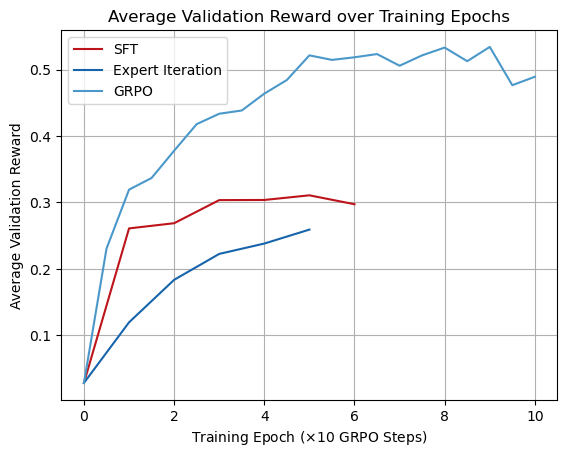

In [52]:
def load_json(file):
    with open(file, 'r') as f:
        data = json.load(f)
    return data

sft_filt = load_json('logs/sft_exp_filt/eval_log.json')
exi_128_30 = pd.read_csv('logs/exi_exp_128_30/exi_exp_128_30_data.csv')
grpo = load_json('logs/grpo_clip_wostdNorm_woLenNorm_LR_3em5/eval_log.json')
zero_shot = [sft_filt[0]['eval/reward_total']]
zero_incorrect = [sft_filt[0]['eval/incorrect_length']]
zero_correct = [sft_filt[0]['eval/correct_length']]

plt.plot([sft_filt[i]['eval/reward_total'] for i in range(len(sft_filt))], label='SFT', color=colorsR[0])
exi_128_30 ['eval/reward_total'].plot(color=colors[0], label='Expert Iteration')
plt.plot(np.arange(0,10.5,0.5),zero_shot+[grpo[i]['eval/reward_total'] for i in range(len(grpo))], label='GRPO', color=colors[1])
plt.xlabel(r'Training Epoch ($\times 10$ GRPO Steps)')
plt.ylabel('Average Validation Reward')
plt.title('Average Validation Reward over Training Epochs')
plt.grid(True)
plt.legend()
plt.savefig('./Figs/Average_Validation.png', dpi=300, bbox_inches="tight")
plt.show()

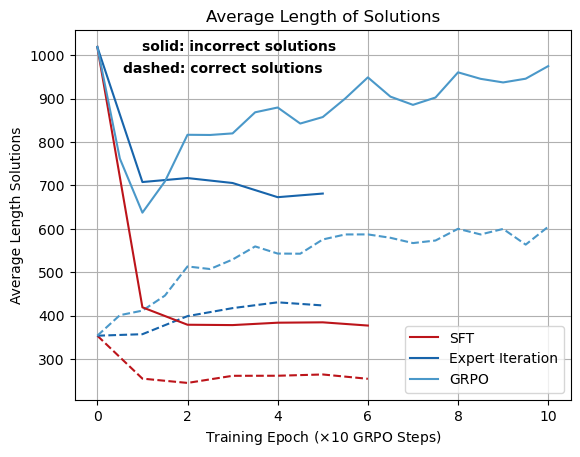

In [79]:
plt.plot([sft_filt[i]['eval/correct_length'] for i in range(len(sft_filt))], '--', color=colorsR[0])
plt.plot(exi_128_30['eval/correct_length'].to_numpy(), color=colors[0], ls='--')
plt.plot(np.arange(0,10.5,0.5),zero_correct+[grpo[i]['eval/correct_length'] for i in range(len(grpo))], '--', color=colors[1])
plt.plot([sft_filt[i]['eval/incorrect_length'] for i in range(len(sft_filt))], label='SFT', color=colorsR[0])
plt.plot(exi_128_30 ['eval/incorrect_length'].to_numpy(), color=colors[0], label='Expert Iteration')
plt.plot(np.arange(0,10.5,0.5),zero_incorrect+[grpo[i]['eval/incorrect_length'] for i in range(len(grpo))], label='GRPO', color=colors[1])
plt.xlabel(r'Training Epoch ($\times 10$ GRPO Steps)')
plt.ylabel('Average Length Solutions')
plt.text(1, 1010, 'solid: incorrect solutions', fontweight='bold')
plt.text(0.56, 960, 'dashed: correct solutions', fontweight='bold')
plt.title('Average Length of Solutions')
plt.grid(True)
plt.legend()
plt.savefig('./Figs/Average_Length.png', dpi=300, bbox_inches="tight")
plt.show()

In [63]:
exi_128_30['eval/correct_length'].to_numpy()

array([353.54225352, 356.99498328, 398.64705882, 417.10332435,
       430.46515533, 423.31635802])